In [17]:
# !pip install albumentations transformers

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm

# Check Apple Silicon (MPS) Availability
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using compute device: {device}")

Using compute device: mps


In [18]:
# 1. Define the Augmentation Pipeline WITH NORMALIZATION
train_transform = A.Compose([
    A.Resize(1024, 1024), 
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2() 
])

# 2. Custom Dataset Class
class UrbanHabitatDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        
        with rasterio.open(img_path) as src_img:
            image = src_img.read()
            image = np.transpose(image, (1, 2, 0)) 
            
        with rasterio.open(mask_path) as src_mask:
            mask = src_mask.read(1)
            
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = mask.to(torch.long)
        return image, mask

# 3. Instantiate
img_dir = "data/model_ready/images"
mask_dir = "data/model_ready/masks"
train_dataset = UrbanHabitatDataset(img_dir, mask_dir, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

print(f"Dataset initialized with {len(train_dataset)} tiles and normalization applied.")

Dataset initialized with 100 tiles and normalization applied.


In [19]:
# Define mapping
id2label = {
    0: 'Impervious / Built-up',
    1: 'Forest & Dense Canopy',
    2: 'Urban Trees & Bushes',
    3: 'Managed Green Spaces',
    4: 'Standard Grassland',
    5: 'Ecologically Valuable Meadow',
    6: 'Agriculture & Orchards',
    7: 'Water Bodies'
}
label2id = {v: k for k, v in id2label.items()}

# Initialize SegFormer
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

print("\nModel successfully initialized on the compute device.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


Model successfully initialized on the compute device.


In [22]:
# 1. Class Weights (Penalizing common classes, rewarding rare ones)
weights = torch.tensor([1.0, 5.0, 2.0, 2.0, 5.0, 3.0, 10.0, 10.0]).float().to(device)

# 2. Setup Optimizer and Loss
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss(weight=weights, ignore_index=255)

model.train()
epochs = 30
patience = 5
best_loss = float('inf')
epochs_no_improve = 0

print(f"Starting optimized training on {device}...")
history_loss = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader, desc="Training Batches"):
        
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(pixel_values=images)
        logits = outputs.logits
        
        # Upsample predictions dynamically to match mask size
        upsampled_logits = F.interpolate(
            logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
        )
        
        loss = loss_fn(upsampled_logits, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Average Training Loss: {avg_loss:.4f}")
    history_loss.append(avg_loss)
    
    # Early Stopping & Model Saving
    if avg_loss < best_loss:
        best_loss = avg_loss
        epochs_no_improve = 0
        os.makedirs("models/best_prototype", exist_ok=True)
        model.save_pretrained("models/best_prototype")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")
        
    if epochs_no_improve >= patience:
        print(f"\n🛑 Early stopping triggered after {epoch+1} epochs! Best model saved.")
        break

Starting optimized training on mps...

Epoch 1/30


Training Batches: 100%|█████████████████████████| 25/25 [00:14<00:00,  1.76it/s]

Average Training Loss: 1.6746


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 2/30


...

Average Training Loss: 1.5767
No improvement for 3 epochs.

Epoch 6/30


Training Batches: 100%|█████████████████████████| 25/25 [00:14<00:00,  1.75it/s]


Average Training Loss: 1.6273
No improvement for 4 epochs.

Epoch 7/30


Training Batches: 100%|█████████████████████████| 25/25 [00:14<00:00,  1.75it/s]

Average Training Loss: 1.6060
No improvement for 5 epochs.

🛑 Early stopping triggered after 7 epochs! Best model saved.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

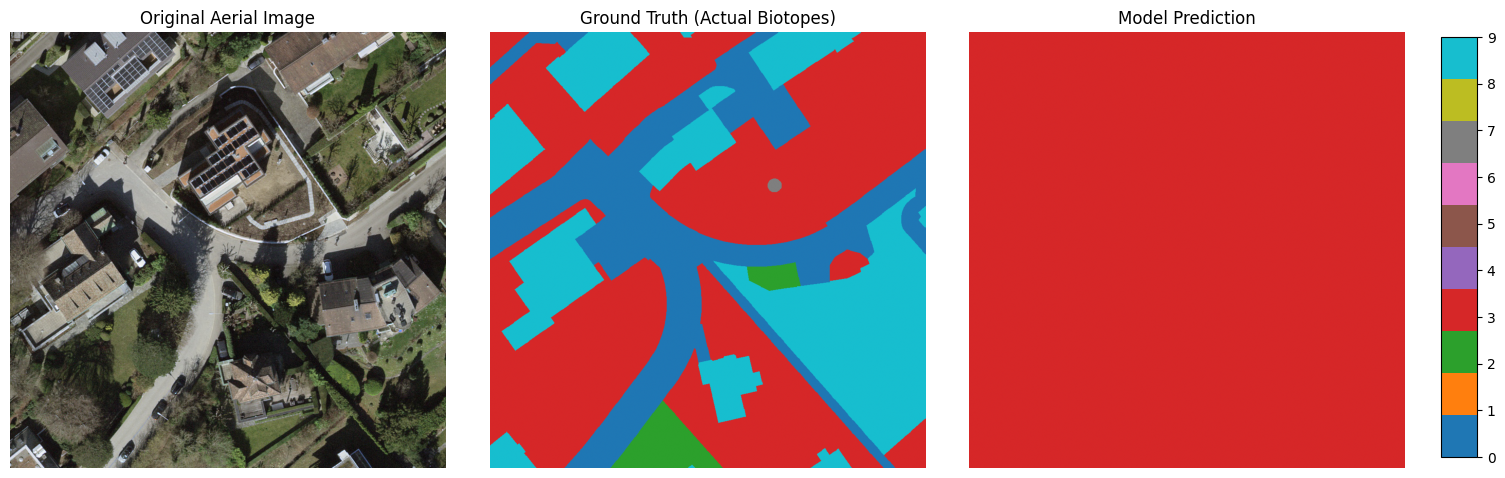

In [23]:
# Load the best model weights we just saved
model = SegformerForSemanticSegmentation.from_pretrained("models/best_prototype").to(device)
model.eval()

# Grab a single batch
images, masks = next(iter(train_loader))
input_image = images[0].unsqueeze(0).to(device)
ground_truth = masks[0].numpy()

with torch.no_grad():
    outputs = model(pixel_values=input_image)
    logits = F.interpolate(
        outputs.logits, size=(1024, 1024), mode="bilinear", align_corners=False
    )
    predicted_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

# Reverse normalization for plotting
img_display = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_display)
axs[0].set_title("Original Aerial Image")
axs[0].axis('off')

axs[1].imshow(ground_truth, cmap='tab10', vmin=0, vmax=9)
axs[1].set_title("Ground Truth (Actual Biotopes)")
axs[1].axis('off')

im = axs[2].imshow(predicted_mask, cmap='tab10', vmin=0, vmax=9)
axs[2].set_title("Model Prediction")
axs[2].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
fig.colorbar(im, cax=cbar_ax)
plt.subplots_adjust(wspace=0.1, right=0.9)
plt.show()

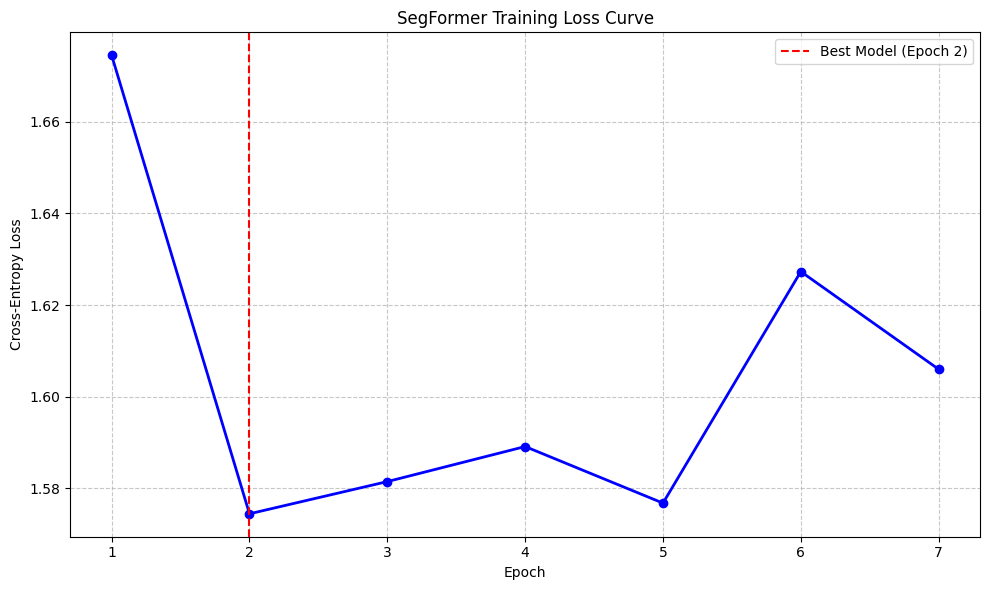

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_loss) + 1), history_loss, marker='o', linestyle='-', color='b', linewidth=2)

plt.title("SegFormer Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.7)

best_epoch = history_loss.index(min(history_loss)) + 1
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

plt.legend()
plt.tight_layout()
plt.show()